

---
## **How does the brain generate movement? Motor manifold discovery via dynamical systems**

---

Arthur Pellegrino, Isabel Cornacchia, Angus Chadwick | University of Edinburgh, School of Informatics | *Bio-inspired deep learning workshop*




## **Introduction**

Neuroscience studies how the brain processes information to produce behaviour, and studying how variables of the world are *represented* in neural activity is central to tackling this question. A topic of particular interest is the study of how the brain generates *movement*. This question is often explored by recording from monkeys performing movements and observing of their neural activity changes as a function of these movements.

**Task description.** In this project you will study neural recordings during a movement task. The subject -- a monkey -- is asked to move a cursor on the screen to reach a target by moving a joystick. While the monkey performed the task, neural activity was recorded from the primary motor cortex, an area of the brain involved in motor execution.

<p align="center">
  <img src="https://drive.google.com/uc?id=1Ouv2l8-8GcvsVBVttThsk_9OyQLFffjy" width="450">
</p>

**Figure 1.** **A.** A monkey was trained to move a joystick with their hand to reach a target on the screen.  **B.** In the meantime, populations of neurons were recorded in brain areas associated to movement.

**Pre-processing.** This task was repeated by the animal several hundreds of time. Each repetition is commonly called a "trial", each producing a neural data matrix of shape *time x neuron*, overall  making a 3D array (also called tensor) of shape *trial x time x neuron*. The targets on the screen were varied within a discrete set of 8 angles $\theta_{target}$, and we call such experimental variable of a task a "condition". The trials were averaged within each condition to produce a tensor of shape *condition x time x neuron*.

**Note.** This dataset is part of published work [1] but the data itself is not publicly available. We have shared part of it for the purpose of this project but please do not share.

## Loading the data

In [4]:
import gdown
import numpy as np
import pickle
from scipy.ndimage import gaussian_filter1d

# This will download the dataset stored in the Google drive
#!gdown 13uJppggakD-fe_doa1rQbVoWwvIn4s1a
!pip install git+https://github.com/arthur-pe/mdds_workshop.git
!pip install umap-learn
!pip install tabulate
!pip install optuna
!pip install plotly


Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/arthur-pe/mdds_workshop.git to c:\users\pizzi\appdata\local\temp\pip-req-build-jenpr8fy
  Resolved https://github.com/arthur-pe/mdds_workshop.git to commit fe12079dd71f94c613eba862b199350cdd1f860e
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/arthur-pe/mdds_workshop.git 'C:\Users\Pizzi\AppData\Local\Temp\pip-req-build-jenpr8fy'


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [5]:
def import_data(data_file, sigma=None):

    regions = ['M1']

    with open(data_file, 'rb') as f:
        data = pickle.load(f)

    neural_data = [data[r+'_spikes'] for r in regions]
    #print([[regions[i], neural_data[i].shape[-1]] for i, r in enumerate(regions)])
    neural_data = np.concatenate([data[r+'_spikes'] for r in regions], axis=-1)

    if sigma is not None:
        neural_data = gaussian_filter1d(neural_data.astype(float), axis=1, sigma=sigma)

    times = data['time']

    epochs = ['BL', 'AD', 'WO']

    trial_ids = []
    max_id = 0
    for e in epochs:
        trial_ids.append(np.array(data['trial_id'][data['epoch']==e])+max_id)
        max_id = trial_ids[-1][-1]

    trial_ids = np.concatenate(trial_ids)

    condition = data['condition']

    neural_data, condition = neural_data[data['epoch']=='BL'], condition[data['epoch']=='BL']

    condition = condition/(np.max(condition)+1)

    neural_data = neural_data[:, (times<0.4) & (times>=-0.4)]


    neural_data = neural_data/neural_data.std()
    position_kinem=data['pos']
    #print(position_kinem.shape)
    #print("\n",np.sum(data['epoch']=='BL')," over ",(data['epoch']=='BL').shape);

    position_kinem=position_kinem[data['epoch']=='BL',:,:]
    position_kinem=position_kinem[:, (times<0.4) & (times>=-0.4)]

    times = times[(times<0.4) & (times>=-0.4)]

    neural_data = neural_data - neural_data[:, times<0.1].mean(axis=(0, 1))
    neural_data = neural_data / (neural_data.std(axis=(0, 1)) + 10 ** -6)
    return neural_data, condition, times,position_kinem

In [6]:
data_file = 'reach.pkl'
data, condition, times,kin_pos = import_data(data_file, sigma=4)

Y = kin_pos

print("kin shape",kin_pos.shape)
print("neural data_shape ", data.shape)
print(data.shape, condition.shape, times.shape)

kin shape (218, 80, 2)
neural data_shape  (218, 80, 95)
(218, 80, 95) (218,) (80,)


## Data information

The neural data consists of a tensor of shape `condition x time x neuron = 218 x 80 x 95`. The condition is an array containing a label for the angle of the target that the animal was instructed to reach (8 unique values $\in[0,1]$).

In [7]:
angle_order = np.unique(condition)
angle_order


array([0.   , 0.125, 0.25 , 0.375, 0.5  , 0.625, 0.75 , 0.875])

In [8]:
color = np.outer(condition, np.ones((data.shape[1]))).flatten()

# Position Trajectories

In [9]:
Y_stacked = np.vstack(Y)
Y_stacked.shape, color.shape

((17440, 2), (17440,))

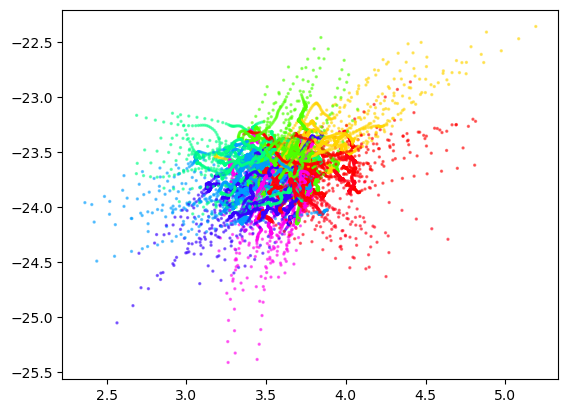

In [10]:
# prompt: do a 3d scatter plot of X_pca with matplotlib

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.scatter(Y_stacked[:, 0], Y_stacked[:, 1], c=color, alpha=0.5, s=2,cmap='hsv')

## PCA

First, to get a sense of the structure of the data, apply PCA to them.

* To the last time point i.e. a slice of your tensor of shape *condition x neuron*. Make a scatter plot in a 2D PCA space.
* To the full data by unfolding the tensor into a *(condition x time) x neuron* matrix. Make a plot of the trajectories in a 3D PCA space.

If you color the trajectories according to the condition, what do you observe?

In [11]:
X_stacked = np.vstack(data)
U, S, Vt = np.linalg.svd(X_stacked, full_matrices=False)
X_pca = U[:, :3] @ np.diag(S[:3])
X_pca.shape, condition.shape

((17440, 3), (218,))

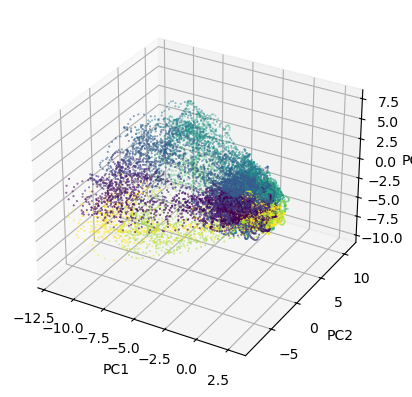

In [12]:
# prompt: do a 3d scatter plot of X_pca with matplotlib

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],s = 0.15, c = color)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()


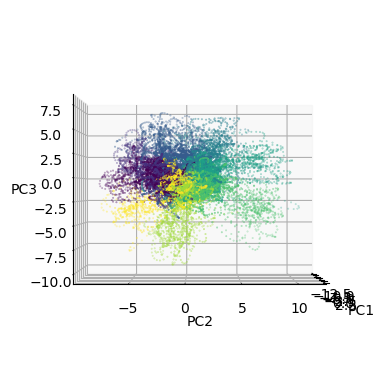

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],s = 0.15, c = color)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(elev=0, azim=0)  # elevation and azimuth angles

plt.show()



In [14]:
X_last_time = X_pca.reshape(data.shape[0], data.shape[1], -1).mean(axis=1)

X_last_time.shape

(218, 3)

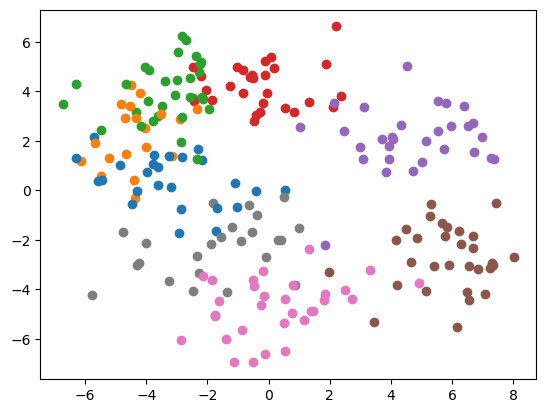

In [15]:
X_pca.shape
X_pca_reshape=X_pca.reshape((data.shape[0],data.shape[1],-1));
X_pca_reshape.shape
for i in range(data.shape[0]):
  colo="C"+str(int(condition[i]*8))
  plt.plot(X_pca_reshape[i,-1,1],X_pca_reshape[i,-1,2],c=colo,marker="o")
plt.show()


In [16]:
import umap.umap_ as umap
um = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.0,#0.01,
    metric='euclidean',
    verbose=True
)
X_umap = um.fit_transform(X_stacked)

UMAP(min_dist=0.0, n_neighbors=30, verbose=True)
Thu Apr 24 13:35:38 2025 Construct fuzzy simplicial set
Thu Apr 24 13:35:38 2025 Finding Nearest Neighbors
Thu Apr 24 13:35:38 2025 Building RP forest with 12 trees
Thu Apr 24 13:35:40 2025 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	 4  /  14
	Stopping threshold met -- exiting after 4 iterations
Thu Apr 24 13:35:48 2025 Finished Nearest Neighbor Search
Thu Apr 24 13:35:49 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Thu Apr 24 13:35:52 2025 Finished embedding


In [17]:
X_umap_0 = um.transform(data[0,:,:])
X_umap_1 = um.transform(data[1,:,:])

Thu Apr 24 13:35:53 2025 Worst tree score: 0.90235092
Thu Apr 24 13:35:53 2025 Mean tree score: 0.90636946
Thu Apr 24 13:35:53 2025 Best tree score: 0.90963303
Thu Apr 24 13:35:54 2025 Forward diversification reduced edges from 523200 to 66145
Thu Apr 24 13:35:56 2025 Reverse diversification reduced edges from 66145 to 66145
Thu Apr 24 13:35:57 2025 Degree pruning reduced edges from 59468 to 59468
Thu Apr 24 13:35:57 2025 Resorting data and graph based on tree order
Thu Apr 24 13:35:57 2025 Building and compiling search function


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


In [18]:
X_umap_2 = um.transform(data[2,:,:])
X_umap_3 = um.transform(data[3,:,:])

Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


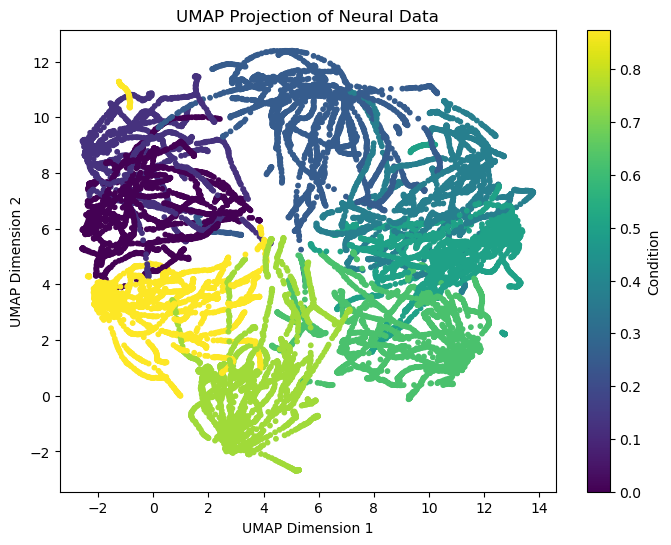

In [19]:
# prompt: Plot X_umap in a 2 d plot

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=color, s=10)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Neural Data")
plt.colorbar(label="Condition")
plt.show()


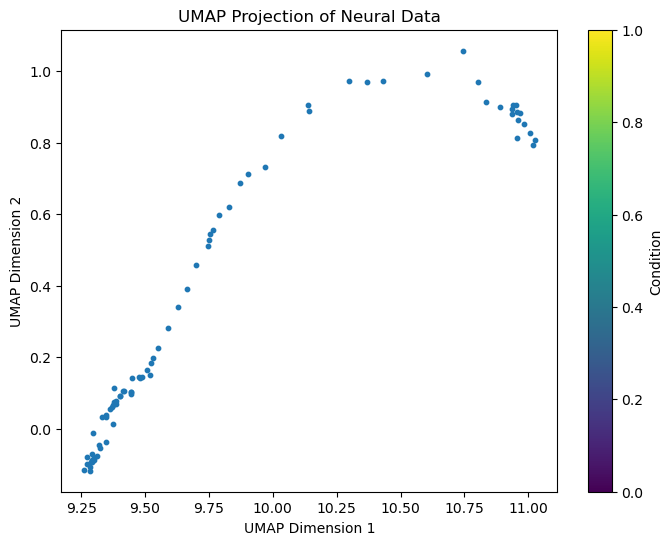

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_umap_1[:, 0], X_umap_1[:, 1], s=10)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Neural Data")
plt.colorbar(label="Condition")
plt.show()

## MDDS application

The results of PCA are limited in two key ways:
1. They assume that the neural representation of time lives in a flat subspace, as opposed to a curved manifold.
2. They don't provide hints as to the *computations* that are performing by the brain on this representation. In particular, we still don't know the dynamical systems underlying the data.

To address this you'll fit MDDS to the data. You can refer to our [preprint](https://drive.google.com/file/d/1rTJfntd2tC6JkylfUdq6UeehjXiFNAnS/view?usp=drive_link) for the details of the method. The key insight of the method is that near a point on the manifold, the *dynamics*, that is the time derivative of the neural trajectories $\frac{d\mathbf{x}(t)}{dt}:=\mathbf{\dot x}(t)$, are constrained to the vector space that is tangent to the manifold. Conversely, the manifold is defined by the tangent space along with a distinguished point. Therefore, parameterizing dynamics on a manifold is equivalent to dynamically choosing a vector of the tangent space to move along:

$$
  \mathbf{\dot x} = c_1(t)\mathbf{f}_1(\mathbf{x}) + ... + c_k(t)\mathbf{f}_k(\mathbf{x})  
$$
where $\mathbf{x}(t)\in \mathbb{R}^n$ is the state of the system, $\mathbf{f}_i:\mathbb{R}^n \rightarrow \mathbb{R}^n$ a vector field for $n$ neurons$^{*}$, and $k$ is the dimension of the tangent space (and therefore that of the manifold).

We can then fit the parameters of the model (find the optimal $c$'s and $\mathbf{f}'s$) to minimize the distance between the datapoints and points along the trajectories of the model.

<p align="center">
  <img src="https://drive.google.com/uc?id=1V9wL8vDn2lNqQYeu-0GjiNDuaJnDcNMn" width="400">
</p>

**Figure 2: Manifold discovery via dynamical systems.** (Left) trajectories on a manifold have derivatives constrained to the space that is tangent to the manifold. (Right) the manifold is inferred by fitting the model parameters to minimize the distance between the trajectories and data points.

For the sake of having a more interpretable model, you can use *linear vector fields*. That is:
$$
  \mathbf{f}_i(\mathbf{x}) = W_i\mathbf{x}(t)
$$
where $\mathbf{W}_i\in\mathbb{R}^{n \times n}$ is a matrix describing the interactions between the variables of the system. There are other parametrisations available if you want to relax this assumption.

**Optional.** In fact, if the manifold is embedded within a lower-dimensional subspace of the space of the recorded neurons, we may need fewer than $n$ variables to describe the activity of the $n$ recorded neurons. For example, we could choose to have an $m$-dimensional latent space and decode from it as $\mathbf{y}(t)=D\mathbf{x}(t)$ where $D\in \mathbb{R}^{n \times m}$ and $\mathbf{y}(t)$ is the data.

* Apply MDDS (already done for you below)
* Compute how much variance MDDS explains as a function of the manifold dimensionality (you can access the data estimate in `data_estimate.npy`)
* Compare that to how much variance a subspace manifold explains as a function of its dimensionality
* Try to explain why $2$ might be a theoretically sound dimensionality for the manifold

In [21]:

from IPython.display import clear_output

clear_output()

import mdds
from mdds import utils

import matplotlib

As in most ML methods, there are a lot of hyperparameters. We've set them to reasonable values for you.

In [22]:
p = {

'seed' : 42,

'save_dir': utils.make_directory(), # Where the model etc... is saved

'manifold_dim': 2, # Intrinsic dim (to be renamed)
'embedding_dim' : 10, # Embedding dim (MDDS's dynamics can be of a different dimension than the number of data neurons).

'frobenius_penalty': 0.01, # Loss = ||data - mdds|| + frobenius_penalty*sum(LieBrackets)

'batch_prop': 0.5, # What fraction of the data to use in each iteration (i.e. minibatch)
'max_iterations': 1800,

'learning_rate': 0.01, # 0.05 - 0.0001
'weight_decay': 0.01, # Regularization on the model's parameters (0, 0.1 or 1.0)
'min_std_test_loss': 0.001,
'min_test_iterations': 100, # If std of test_loss over the past min_test_iterations is less than min_std_test_loss then exit.

'test_frequency': 100, # Number of iterations in-between each plots update
'mesh_size': 61, # Plotted manifold mesh size

# ODE solver hyperparameters (see Driffrax)
'rtol': 0.01,
'atol': 0.001,

# If data has T time bins then the controls (i.e. c's) will be a linear interpolation of controls_interpolation_freq * T points
'controls_interpolation_freq': 1.0,

# The mode parameterizing the vector fields
'vector_fields_class': 'LinearMDDS_', # or DNNMDDS for a nonlinear vector field, in which case:
#'vector_fields_hyperparameters':{
#  'mlp_width': 10,
#  'mlp_depth': 2,
#  'activation': jnp.tanh
#},

'optimized': ['controls', 'vector_fields', 'decoder'], # Which of ['controls', 'vector_fields', 'decoder'] to optimize

}

directory: ./runs/all/24-04-2025_13_36_01


In [23]:
data.shape

(218, 80, 95)

In [24]:
#mdds.fit(data, condition, cmap_condition=matplotlib.colormaps['hsv'], **p)

In [25]:
#from google.colab import drive
#drive.mount('/content/drive')

## Analysis of the MDDS solution
A common question in neuroscience is: how much information about a variable (e.g., a stimulus or behavioral parameter) is encoded in neural activity?

One way to approach this is through decoding — trying to predict the variable of interest from the neural responses.

* Linearly decode the target angle from the neural activity (e.g. at the final time point)

This will tell us how well the neural population represents the angle, using only a linear readout.

* Repeat this with the activity from MDDS (`latent_factors.npy` or `data_estimate.npy`). Is there one representation that allows better (linear) decoder? What would this imply for the system?

##Classification of Target ANGLE

In [26]:
data.shape
raw_data_last_time=data[:,-1,:].squeeze()
raw_data_last_time.shape
print(np.unique(condition))

X_pca_last_time_selected=X_pca_reshape[:,-1,1:3]
X_pca_last_time_selected.shape

X_umap_last_time=X_umap.reshape((data.shape[0],data.shape[1],-1));
X_umap_last_time=X_umap_last_time[:,-1,:].squeeze()
X_umap_last_time.shape

X_latent_MDDS=np.load("runs\main_MDDS_Model\latent_factors.npy")
X_latent_MDDS_stacked = np.vstack(X_latent_MDDS)
X_latent_MDDS_last_time=X_latent_MDDS[:,-1,:].squeeze()
print(X_latent_MDDS_last_time.shape)#

X_data_MMDS=np.load("runs\main_MDDS_Model\data_estimate.npy")
X_data_MDDS_stacked = np.vstack(X_data_MMDS)
X_data_MMDS_last_time=X_data_MMDS[:,-1,:].squeeze()
print(X_data_MMDS_last_time.shape)


[0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875]
(218, 2)
(218, 95)


<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Pizzi\AppData\Local\Temp\ipykernel_30964\1015472610.py:13: SyntaxWarning: invalid escape sequence '\m'
  X_latent_MDDS=np.load("runs\main_MDDS_Model\latent_factors.npy")
C:\Users\Pizzi\AppData\Local\Temp\ipykernel_30964\1015472610.py:18: SyntaxWarning: invalid escape sequence '\m'
  X_data_MMDS=np.load("runs\main_MDDS_Model\data_estimate.npy")


In [27]:
#!pip install tabulate
from tabulate import tabulate
from sklearn.model_selection import StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import matthews_corrcoef
import numpy as np

# Define stratified K-fold


kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)
classes=np.array([np.argwhere(np.unique(condition) == e).flatten()[0] for e in condition])
#print(classes)
# Store accuracy per fold
matt_coeffs =[]
matt_coeffs_items=[]
for X,name in [(raw_data_last_time,"RAW 95-D"),
               (X_pca_last_time_selected,"PCA 2-D"),
               (X_umap_last_time,"UMAP 2-D"),
               (X_latent_MDDS_last_time,"MDDS LATENT c(t) 2-D"),
               (X_data_MMDS_last_time,"MDDS GENERATED_DATA y(t) 95-D")
               ]:
  l=[];
  for train_idx, val_idx in kfold.split(X, classes):
      lda = LDA(n_components=None)
      #print(X[train_idx])
      lda.fit(X[train_idx,:], classes[train_idx])
      predictions = lda.predict(X[val_idx,:])

      y_val=classes[val_idx]

      c_m = matthews_corrcoef(y_val, predictions)
      l.append(c_m)
  matt_coeffs.append((name,np.mean(l),np.std(l)))
  matt_coeffs_items.append((name,l.copy()))
print("CLASSIFICATION RESULTS")
print(tabulate(matt_coeffs, ["Model name", "Matthews Coeffs[-1,1]","std Matthews coeffs"], tablefmt="github"))



CLASSIFICATION RESULTS
| Model name                    |   Matthews Coeffs[-1,1] |   std Matthews coeffs |
|-------------------------------|-------------------------|-----------------------|
| RAW 95-D                      |                0.834932 |             0.0723518 |
| PCA 2-D                       |                0.756027 |             0.0513849 |
| UMAP 2-D                      |                0.913584 |             0.0337597 |
| MDDS LATENT c(t) 2-D          |                0.826322 |             0.047937  |
| MDDS GENERATED_DATA y(t) 95-D |                0.917153 |             0.0193203 |


## Regression Model

Regression from position to dim reduction latent variables

In [28]:
X_umap.shape, Y_stacked.shape, X_latent_MDDS_stacked.shape, X_data_MDDS_stacked.shape, X_pca.shape

((17440, 2), (17440, 2), (17440, 2), (17440, 95), (17440, 3))

In [ ]:
#!pip install tabulate
from tabulate import tabulate
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

# Define stratified K-fold

R2_scores = []
kfold = KFold(n_splits=5, shuffle=True, random_state=10)
for name, X_ in [
    ("umap 2",X_umap),
    ("pca 3",X_pca), 
    ("neural 95",X_stacked),
    ("mdds 95", X_data_MDDS_stacked),
    ("mdds 2", X_latent_MDDS_stacked),
    ("pca 15",X_pca95), 
    ]:
    for train_idx, val_idx in kfold.split(X_):
        X_train = np.hstack([X_[train_idx, :], np.ones((X_[train_idx, :].shape[0], 1))])
        X_val = np.hstack([X_[val_idx, :], np.ones((X_[val_idx, :].shape[0], 1))])
        y_train = Y_stacked[train_idx]
        y_val = Y_stacked[val_idx]

        A = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
        y_pred = X_val @ A

        r2 = r2_score(y_val, y_pred)
        R2_scores.append({"name": name, "R2": r2})

R2_scores = pd.DataFrame(R2_scores)
R2_scores = R2_scores.groupby("name").agg(["mean", "std"])
R2_scores.sort_values(by=("R2", "mean"), ascending=False, inplace=True)
R2_scores

R2          
               mean       std
name                         
neural 95  0.415516  0.009050
mdds 95    0.366205  0.015794
umap 2     0.345920  0.010999
mdds 2     0.294795  0.016393
pca 3      0.226493  0.014698

# UMAP hyperparameter optimization

In [ ]:
import optuna
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import numpy as np

import umap.umap_ as umap
"""
A_best = None
R2_best = -np.inf

# Define the objective function for Optuna
def objective(trial):
    global A_best, R2_best
    # Suggest hyperparameters
    n_neighbors = trial.suggest_int("n_neighbors", 5, 50)
    min_dist = trial.suggest_float("min_dist", 0.0, 0.5)
    n_components = trial.suggest_int("n_components", 2, 10)

    # Initialize UMAP with suggested hyperparameters
    um = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric="euclidean"
    )

    # Perform K-Fold cross-validation
    kfold = KFold(n_splits=5, shuffle=True)
    r2_scores = []
    A_s = []

    for train_idx, val_idx in kfold.split(X_stacked):
        X_train, X_val = X_stacked[train_idx], X_stacked[val_idx]
        Y_train, Y_val = Y_stacked[train_idx], Y_stacked[val_idx]

        # Fit UMAP on training data
        X_train_umap = um.fit_transform(X_train)
        X_val_umap = um.transform(X_val)

        # Linear regression to predict Y from UMAP-transformed X
        X_train_umap = np.hstack([X_train_umap, np.ones((X_train_umap.shape[0], 1))])
        X_val_umap = np.hstack([X_val_umap, np.ones((X_val_umap.shape[0], 1))])
        A = np.linalg.solve(X_train_umap.T @ X_train_umap, X_train_umap.T @ Y_train)
        Y_pred = X_val_umap @ A

        # Compute R2 score
        r2 = r2_score(Y_val, Y_pred)
        r2_scores.append(r2)
        A_s.append(A.copy())


    mean_r2 = np.mean(r2_scores)
    #Saving best A and R2
    if mean_r2 > R2_best:
        R2_best = mean_r2
        A_best = A_s[np.argmax(r2_scores)].copy()

    # Return the mean R2 score across folds
    return np.mean(r2_scores)

# Create an Optuna study and optimize
study = optuna.create_study(direction="maximize", study_name="UMAP Hyperparameter Optimization")
study.optimize(objective, n_trials=40, n_jobs=10)

# Print the best hyperparameters and the corresponding R2 score
print("Best hyperparameters:", study.best_params)
print("Best R2 score:", study.best_value)
"""

[I 2025-04-24 13:36:02,890] A new study created in memory with name: UMAP Hyperparameter Optimization
[I 2025-04-24 13:38:23,332] Trial 5 finished with value: 0.32430738991772945 and parameters: {'n_neighbors': 13, 'min_dist': 0.45982897849679377, 'n_components': 10}. Best is trial 5 with value: 0.32430738991772945.
[I 2025-04-24 13:38:28,128] Trial 6 finished with value: 0.3245653314744842 and parameters: {'n_neighbors': 19, 'min_dist': 0.05487627679739815, 'n_components': 4}. Best is trial 6 with value: 0.3245653314744842.
[I 2025-04-24 13:38:29,793] Trial 9 finished with value: 0.2999238221592952 and parameters: {'n_neighbors': 12, 'min_dist': 0.49382344101488357, 'n_components': 6}. Best is trial 6 with value: 0.3245653314744842.
[I 2025-04-24 13:38:32,887] Trial 0 finished with value: 0.35467831083750034 and parameters: {'n_neighbors': 33, 'min_dist': 0.21888196337754273, 'n_components': 10}. Best is trial 0 with value: 0.35467831083750034.
[I 2025-04-24 13:38:37,438] Trial 2 fini

Best hyperparameters: {'n_neighbors': 29, 'min_dist': 0.14715882726479382, 'n_components': 10}
Best R2 score: 0.35861069050521605


In [ ]:
best_param= {"n_neighbors":29,"min_dist":0.14715882726479382,"n_components":10};
import pickle
#with open("best_param.pkl", "wb") as f:
#    pickle.dump(best_param, f)
#with open("best_A_R2.pkl", "wb") as f:
#    pickle.dump(A_best, f)
#with open("best_R2.pkl", "wb") as f:
#    pickle.dump(R2_best, f)
with open("best_param.pkl", "rb") as f:
    best_param = pickle.load(f)
with open("best_A_R2.pkl", "rb") as f:
    A_best = pickle.load(f)
with open("best_R2.pkl", "rb") as f:
    R2_best = pickle.load(f)

In [ ]:
# Apply UMAP with the best hyperparameters
best_umap = umap.UMAP(
    n_neighbors=best_param["n_neighbors"],
    min_dist=best_param["min_dist"],
    n_components=best_param["n_components"],
    metric="euclidean",
    random_state=11
)
X_umap_best = best_umap.fit_transform(X_stacked)

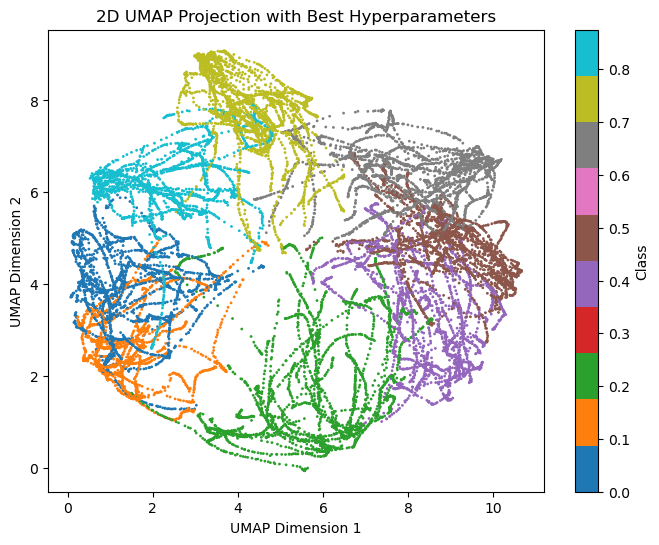

In [32]:
# Plot the 2D scatter plot with tab10 discrete color scheme
plt.figure(figsize=(8, 6))
plt.scatter(X_umap_best[:, 0], X_umap_best[:, 1], c=color, s=1, cmap='tab10')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("2D UMAP Projection with Best Hyperparameters")
plt.colorbar(label="Class")
plt.show()



In [37]:
print(X_umap_best.shape)
A_best.shape

(17440, 10)


(11, 2)

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

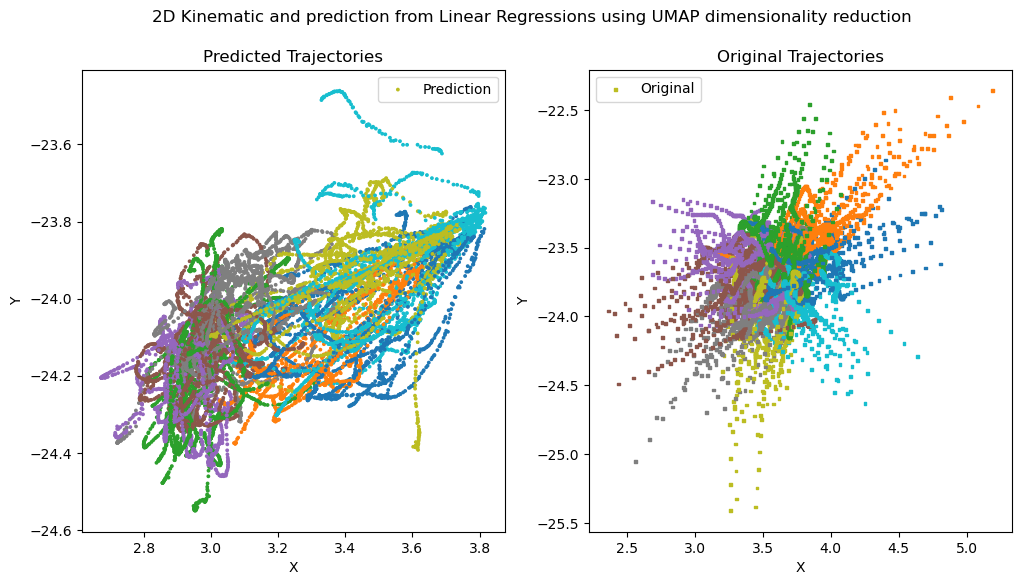

In [ ]:
import pandas as pd

kfold = KFold(n_splits=5, shuffle=True)
r2_scores = []

X_umap_with_biases = np.hstack([X_umap_best, np.ones((X_umap_best.shape[0], 1))])

Y_pred = X_umap_with_biases @ A_best

# Plot the 2D scatter plot with tab10 discrete color scheme
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].scatter(Y_pred[:, 0], Y_pred[:, 1], c=color, s=3, cmap='tab10', label="Prediction", marker='o')
axs[0].set_title("Predicted Trajectories")
axs[0].set_xlabel("X")
axs[0].set_ylabel("Y")
axs[0].legend()

axs[1].scatter(Y_stacked[:, 0], Y_stacked[:, 1], c=color, s=4, cmap='tab10', label="Original", marker='s')
axs[1].set_title("Original Trajectories")
axs[1].set_xlabel("X")
axs[1].set_ylabel("Y")
axs[1].legend()

plt.suptitle("2D Kinematic and prediction from Linear Regressions using UMAP dimensionality reduction")
plt.show()
#plt.scatter(Y_stacked[:, 0], Y_stacked[:, 1], c=color, s=4, cmap='tab10', label="Original ", marker='s')
#
##markerfacecolor='none', markeredgecolor='blue', for open cirles
#plt.xlabel("X")
#plt.ylabel("Y")
#plt.title("2D Kinematic and prediction from Linear Regressions using UMAP dimensionality reduction")
#plt.colorbar(label="Class")
#plt.legend()
#plt.show()



## Big question: how is the brain solving this task?
The ultimate goal is to form a hypothesis for how the brain solves this task.

What is a (minimal) computational model that could explain the data?

There are many ways to address this. For example, you could start from the data and the properties extracted with the exploratory analysis (e.g. PCA). Or, you could consider the data and insights extracted via MDDS to inform your model. Alternatively, a common approach in neuroscience is to train a recurrent neural network (RNN) - which is a dynamical system - to solve the same task and compare that solution with your data and gain some insights into how the task *could* be solved.

How much can any of these approaches really inform us about the brain? How much does the available data constrains our models? For example, what can we *not* say about this system given this data?

**Other potential questions**

- For BCI application, consider a fixed *decoder*. How would it change the solution?

## References

[1] Perich, Matthew G., Juan A. Gallego, and Lee E. Miller. "A neural population mechanism for rapid learning." Neuron 100.4 (2018): 964-976.